In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

df = pd.read_csv("D:/DS_AI_Internship/data/hiring.csv")
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [2]:
exp_map = {
    "zero":0, "one":1, "two":2, "three":3, "four":4,
    "five":5, "six":6, "seven":7, "eight":8, "nine":9, "ten":10
}

df.experience = df.experience.map(exp_map)

In [3]:
df.experience = df.experience.fillna(0)

df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(
    df['test_score(out of 10)'].median()
)

In [4]:
X = df[['experience','test_score(out of 10)','interview_score(out of 10)']]
y = df['salary($)']

In [5]:
model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
model.predict(pd.DataFrame([[2,9,6]], columns=X.columns))

array([57403.91636243])

In [7]:
model.predict(pd.DataFrame([[12,10,10]], columns=X.columns))

array([79138.40026552])

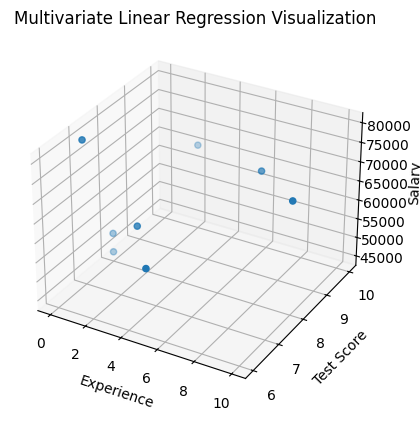

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['experience'],
           df['test_score(out of 10)'],
           df['salary($)'])

ax.set_xlabel("Experience")
ax.set_ylabel("Test Score")
ax.set_zlabel("Salary")

plt.title("Multivariate Linear Regression Visualization")
plt.show()

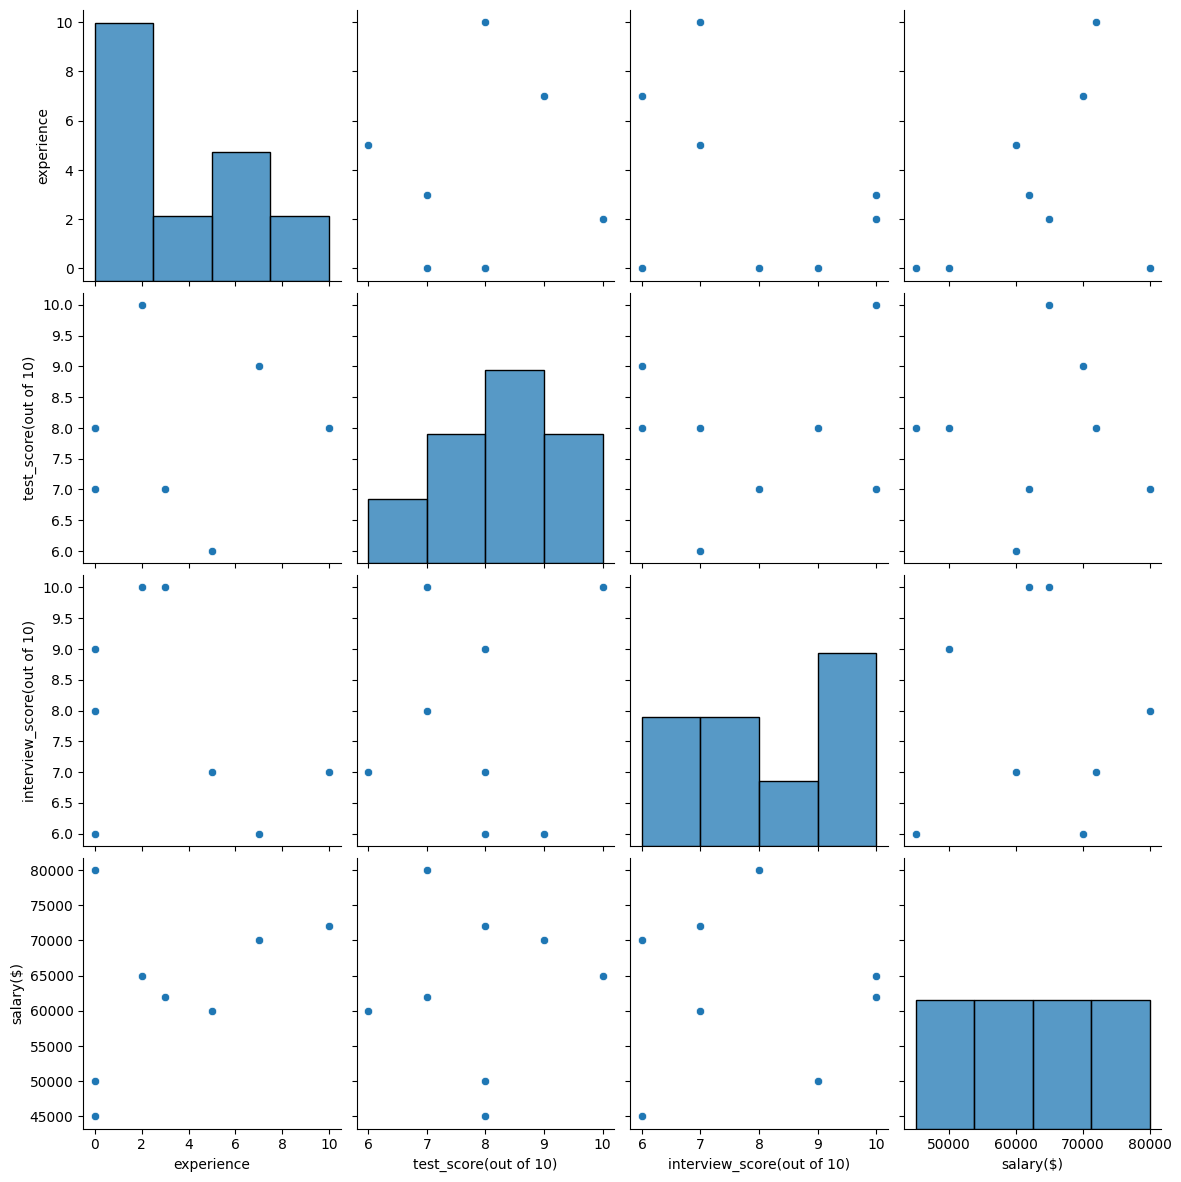

In [9]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.pairplot(df, height=3)
plt.show()

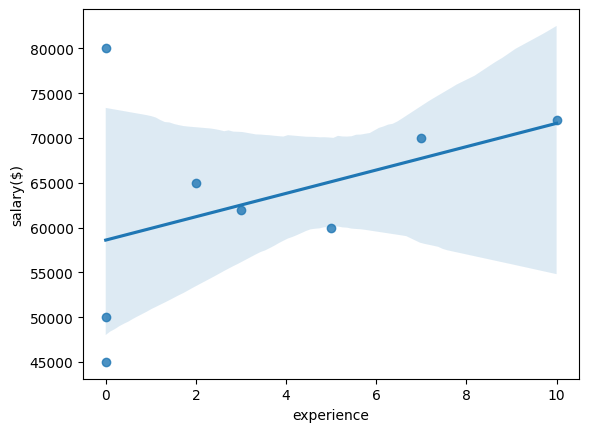

In [10]:
sns.regplot(x="experience", y="salary($)", data=df)
plt.show()